# 3D Analysis of an Extended Source

In this example we fit the spectum and spatial extension of RX J1713.7-3946 (called rxj1713 in the following because typing is hard) first jointly and then stacked

## Joint Fit

Load all the relevant modules and set the energy unit to `u.TeV` as we are only dealing with H.E.S.S. data here

Additionally we load the `Gaussian_on_sphere` from `gammapy_plugin.utils.astromodels_functions` and `Cutoff_powerlaw` from `astromodels` for modelling the source later

In [1]:
%matplotlib inline
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astromodels.core.model import Model
from astromodels.core.units import get_units
from astromodels.functions import (
    Log_uniform_prior,
    Cutoff_powerlaw,
    Uniform_prior,
)
from astromodels.sources.extended_source import ExtendedSource
from astropy.coordinates import SkyCoord
from gammapy.data import DataStore
from gammapy.datasets import MapDataset, Datasets
from gammapy.makers import (
    MapDatasetMaker,
    SafeMaskMaker,
)
from gammapy.maps import MapAxis, WcsGeom
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    PowerLawSpectralModel,
    SkyModel,
    GaussianSpatialModel,
    FoVBackgroundModel,
)
from regions import CircleSkyRegion
from threeML import DataList, load_analysis_results
from threeML.bayesian.bayesian_analysis import BayesianAnalysis
from threeML.classicMLE.joint_likelihood import JointLikelihood
from threeML.utils.progress_bar import trange

from gammapy_plugin.converter import AstromodelConverter
from gammapy_plugin.GammapyLike import GammapyLike
from astromodels.functions.functions_2D import Gaussian_on_sphere

get_units().energy = u.TeV

10:15:00 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=332278;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=932986;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/functions.py#45\45]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=278516;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=151463;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/functions.py#67\67]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=7298;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=566502;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/absorption.py#34\34]8;;\
                  available                                                                                        

10:15:01 INFO      Starting 3ML!                                                                     ]8;id=54112;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=973040;file:///home/tobi/sw/threeML/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=874156;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=929202;file:///home/tobi/sw/threeML/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=367883;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=838419;file:///home/tobi/sw/threeML/threeML/__init__.py#136\136]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=998032;file:///home/tobi/sw/threeML/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=108503;file:///home/tobi/sw/threeML/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=485525;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=986427;file:///home/tobi/sw/threeML/threeML/__init__.py#340\340]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=378756;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=767779;file:///home/tobi/sw/threeML/threeML/__init__.py#340\340]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=719798;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=923368;file:///home/tobi/sw/threeML/threeML/__init__.py#340\340]8;;\
                  performances in 3ML                                                                              

Select all the observations within a `5 deg` radius around RX J1713.7-3946

Prepare the geometry by setting the energy axis and `WcsGeom`

In [2]:
datastore = DataStore.from_dir("$GAMMAPY_DATA/hess-dl3-dr1/")

In [3]:
datastore.obs_table[datastore.obs_table["OBJECT"] == "MSH15-52"]

OBS_ID,RA_PNT,DEC_PNT,GLON_PNT,GLAT_PNT,ZEN_PNT,ALT_PNT,AZ_PNT,OBJECT,RA_OBJ,DEC_OBJ,OFFSET_OBJ,ONTIME,LIVETIME,DEADC,TSTART,TSTOP,DATE-OBS,TIME-OBS,DATE-END,TIME-END,N_TELS,TELLIST,QUALITY,MUONEFF,EVENT_COUNT,TARGET_NAME,TARGET_TAG,TARGET_OFFSET,SAFE_ENERGY_LO,SAFE_ENERGY_HI
,deg,deg,deg,deg,deg,deg,deg,,deg,deg,deg,s,s,,s,s,,,,,,,,,,,,deg,TeV,TeV
int64,float32,float32,float32,float32,float32,float32,float32,bytes18,float32,float32,float32,float32,float32,float32,float64,float64,bytes10,bytes12,bytes10,bytes12,int64,bytes7,int64,float32,int64,bytes21,bytes14,float32,float32,float32
20136,228.6125,-58.771667,320.56754,-0.8857012,38.512962,51.487038,195.73102,MSH15-52,228.6125,-59.271667,0.5,1682.0,1521.0269,0.9042966,101962602.0,101964284.0,2004-03-26,02:57:46.184,2004-03-26,03:25:48.184,4,"1,2,3,4",0,1.2132596,11243,MSH 15-52,msh1552,0.38821736,0.40738028,100.0
20137,228.6125,-59.771667,320.04724,-1.7397733,40.21616,49.78384,199.6482,MSH15-52,228.6125,-59.271667,0.5,902.0,819.2054,0.90821,101964441.0,101965343.0,2004-03-26,03:28:25.184,2004-03-26,03:43:27.184,4,"1,2,3,4",0,1.2139559,5693,MSH 15-52,msh1552,0.6156251,0.40738028,100.0


In [4]:
target_position = SkyCoord.from_name("MSH15-52").galactic

selection = dict(
    type="sky_circle",
    frame="galactic",
    lon=target_position.l,
    lat=target_position.b,
    radius="5deg",
)
select_obs_tab = datastore.obs_table.select_observations(selection)

obs = datastore.get_observations(select_obs_tab["OBS_ID"])
print(len(obs))
# Prepare the geometry
energy_axis = MapAxis.from_energy_bounds(0.2, 40.0, 10, per_decade=True, unit="TeV")
energy_axis_true = MapAxis.from_energy_bounds(
    0.1, 100, 20, per_decade=True, unit="TeV", name="energy_true"
)
geom = WcsGeom.create(
    skydir=target_position,
    binsz=0.02,
    width=(6 * u.deg, 6 * u.deg),
    frame="galactic",
    axes=[energy_axis],
)

20


In [5]:
geom

Create the relevant `Makers`

We will also run the `FoVBackgroundMaker` when jointly fitting - this is not needed

We exclude a `1 deg` circle at the source poition for fitting the background models to reduce overestimation of the background


In [6]:
circle = CircleSkyRegion(center=target_position, radius=1 * u.deg)
circle1 = CircleSkyRegion(center=SkyCoord.from_name("HESS J1503-582"), radius=1 * u.deg)
circle2 = CircleSkyRegion(center=SkyCoord.from_name("HESS J1458-608"), radius=1 * u.deg)
circle3 = CircleSkyRegion(center=SkyCoord.from_name("HESS J1458-608"), radius=1 * u.deg)
regions = [circle, circle1, circle2, circle3]
exclusion_mask = ~geom.region_mask(regions=regions)
maker = MapDatasetMaker(
    selection=["counts", "background", "psf", "edisp", "exposure"],
)
safe_mask_maker = SafeMaskMaker(
    methods=["offset-max", "aeff-max", "bkg-peak"], offset_max="2.3 deg"
)
fov_bkg_maker = FoVBackgroundMaker(method="fit", exclusion_mask=exclusion_mask)

NameError: name 'FoVBackgroundMaker' is not defined

And now the datasets as well as the `GammapyPlugin` instances:

Few noteworthy things:
- we set the `FoVBackgroundModel` before and provide a custom `name`. As mentioned before, the background model is fitted afterwards and running the `FoVBackgroundMaker` is not necessary, but here we also print the fitted values from the `FoVBackgroundMaker` to compare to our results later
- in case you want to fit the background before and fix it during the fit you will always have to set the model before providing a non-default name as it defaults to `dataset_name + "-bkg"` which is not compatible with `astromodels`
- the `exclusion_mask` is only used for the `FoVBackgroundMaker` and will _not_ be used later during the acutal sampling
- the used map size of `6deg x 6deg` is fairly large and there are other sources in this region which we do not mask for simplicity: **_This will lead to overestimation of the background and therefore an underestimation of the source's flux!_**
- we set the dataset using default `mode="individual"` as we use on plugin per instance, afterwards we add the corresponding background model, which then gets parsed by `gammapy_plugin` and the normalization is treated as a nuisance parameter
- we used a galactic `WcsGeom` frame and we therefore also use galactic in the plugin

In [ ]:
datasets = Datasets()
gls = []
for o in obs:
    dataset = MapDataset.create(
        geom=geom, energy_axis_true=energy_axis_true, name=f"HESS_{o.obs_id}"
    )
    dataset = maker.run(dataset, o)
    dataset = safe_mask_maker.run(dataset, o)
    bkg_model = FoVBackgroundModel(name=f"{o.obs_id}_bkg", dataset_name=dataset.name)
    dataset.models = [bkg_model]
    dataset = fov_bkg_maker.run(dataset)
    print(
        f"Bkg norm for HESS_{o.obs_id}: {round(bkg_model.parameters['norm'].value,3)} +/- {round(bkg_model.parameters['norm'].error,3)}"
    )
    datasets.append(dataset)

gl = GammapyLike(dataset.name, frame="galactic")
gl.set_datasets(datasets, mode="stacked")
# gl.set_background_models(bkg_model)
gls.append(gl)

## Setting up the Model

Using a exponential cutoff-powerlaw spectral model and a 2D Gaussian spatial one for simplicity

In [ ]:
cpl = Cutoff_powerlaw()
spat = Gaussian_on_sphere(
    lon0=target_position.transform_to("galactic").l.deg,
    lat0=target_position.transform_to("galactic").b.deg,
    sigma=0.5,
)
es = ExtendedSource(source_name="rxj1713", spectral_shape=cpl, spatial_shape=spat)
cpl.K = 5e-15 * u.Unit("TeV-1 cm-2 s-1")
cpl.index = -2 * u.dimensionless_unscaled
cpl.xc = 15 * u.TeV
cpl.piv = 1 * u.TeV
cpl.piv.free = False
cpl.K.prior = Log_uniform_prior(lower_bound=1e-15, upper_bound=1e-14)
cpl.index.prior = Uniform_prior(lower_bound=-3, upper_bound=-1)
cpl.xc.prior = Uniform_prior(lower_bound=1, upper_bound=30)
spat.lon0.free = False
spat.lat0.free = False
spat.sigma.unit = u.deg
spat.sigma.free = True
spat.sigma.prior = Uniform_prior(lower_bound=0.1, upper_bound=1)

model = Model(es)

We can either convert the model before setting it or a `AstromodelConverter` will be created when adding the model to plugins

In [ ]:
conv = AstromodelConverter(model, frame="galactic")

Now adding the model and the converted one to the plugins and specificly including the source. All sources are used by default, here we set it explicitly for no specific reason

In [ ]:
for gl in gls:
    gl.set_sources("rxj1713")
    gl.set_model(model, conv)

This next cell might take hours or days to finish using only a single core. Just skip it and load the result provided in the `result.fits` in the next cell.

In [ ]:
ba = BayesianAnalysis(model, DataList(*gls))
ba.set_sampler("multinest")
ba.sampler.setup()

res = ba.sample(quiet=False)

In [ ]:
# res = load_analysis_results("data/result.fits")
res.display()

Take a look at the corner plot of the source's free paramters:

In [ ]:
fig = res.corner_plot(
    components=[
        "rxj1713.Gaussian_on_sphere.sigma",
        "rxj1713.spectrum.main.Cutoff_powerlaw.K",
        "rxj1713.spectrum.main.Cutoff_powerlaw.index",
        "rxj1713.spectrum.main.Cutoff_powerlaw.xc",
    ]
)
fig.show()

Lets take a look at the differential flux at 1 TeV by integrating over the spatial part - the units of the normalzation `K` are actually `cm-2 TeV-1 s-1 deg-2` and not as stated in the results `cm-2 TeV-1 s-1`

In [ ]:
flux_1tev = res.optimized_model.extended_sources["rxj1713"].spectrum.main.shape(
    1 * u.TeV
) * res.optimized_model.extended_sources[
    "rxj1713"
].spatial_shape.get_total_spatial_integral(
    z=1 * u.TeV
)


samples = res.samples
n_samples = 1000
vals = np.zeros(n_samples)
cpl_copy = Cutoff_powerlaw()
spat_copy = Gaussian_on_sphere(
    lon0=target_position.transform_to("galactic").l.deg,
    lat0=target_position.transform_to("galactic").b.deg,
    sigma=0.5,
)
es_copy = ExtendedSource(
    source_name="dummy", spectral_shape=cpl_copy, spatial_shape=spat_copy
)

for i in trange(n_samples):
    n = np.random.choice(np.arange(samples.shape[-1]))
    spat_copy.sigma.value = samples[0, n]
    cpl_copy.K.value = samples[1, n]
    cpl_copy.index.value = samples[2, n]
    cpl_copy.xc.value = samples[3, n]
    vals[i] = cpl_copy(1) * spat_copy.get_total_spatial_integral()
hpd_1tev = np.array((np.percentile(vals, 2.5), np.percentile(vals, 97.5)))
print(f"Flux: {flux_1tev} +/- {np.abs((hpd_1tev-flux_1tev.value)[::-1])}")
print(f"95% hpd interval: {hpd_1tev}")

Keeping in mind that we are overestimating the background for sure, this is on the order of the value from [H.E.S.S. Collaboration, 2018](http://dx.doi.org/10.1051/0004-6361/201629790), who determined a flux of $2.3\pm0.1\:\mathrm{e}{-11}$ cm-2 s-1 TeV-1



In [ ]:
plt.matshow(res.get_correlation_matrix())
ticks = [
    i.replace("rxj1713.", "")
    .replace("_bkg_norm", "")
    .replace("spectrum.main.Cutoff_powerlaw.", "")
    .replace("HESS_", "")
    .replace("Gaussian_on_sphere.", "")
    .split("_")[0]
    for i in res.optimized_model.free_parameters.keys()
]
plt.xticks(np.arange(19), ticks, rotation=90)
plt.yticks(np.arange(19), ticks)
plt.colorbar()

In [ ]:
datasets_temp = Datasets()
for gl in gls:
    datasets_temp.append(gl.datasets[0])

Taking a look at the energy integrated counts map of these 15 observations, a 2D-Gaussian might not be the best description and a Powerlaw neither ;)

In [ ]:
datasets.stack_reduce().counts.sum_over_axes(keepdims=False).smooth(0.02 * u.deg).plot()

## Stacking the Dataset

We can also speed things a lot by
1. stacking the datasets
2. only fitting the FoVBackgroundModels before hand and fixing their values


In [23]:
datasets_stacked = Datasets()

for o in obs:
    dataset = MapDataset.create(
        geom=geom, energy_axis_true=energy_axis_true, name=f"HESS_{o.obs_id}"
    )
    dataset = maker.run(dataset, o)
    dataset = safe_mask_maker.run(dataset, o)
    bkg_model = FoVBackgroundModel(name=f"{o.obs_id}_bkg", dataset_name=dataset.name)
    dataset.models = [bkg_model]
    dataset = fov_bkg_maker.run(dataset)
    print(
        f"Bkg norm for HESS_{o.obs_id}: {round(bkg_model.parameters['norm'].value,3)} +/- {round(bkg_model.parameters['norm'].error,3)}"
    )
    datasets_stacked.append(dataset)

In [41]:
for d in datasets_stacked:
    print(d)

MapDataset
----------

  Name                            : HESS_20136 

  Total counts                    : 4291 
  Total background counts         : 4328.92
  Total excess counts             : 145.94

  Predicted counts                : 4145.06
  Predicted background counts     : 4145.06
  Predicted excess counts         : nan

  Exposure min                    : 4.16e-03 m2 s
  Exposure max                    : 7.42e+08 m2 s

  Number of total bins            : 2160000 
  Number of fit bins              : 830860 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : 47149.55

  Number of models                : 1 
  Number of parameters            : 3
  Number of free parameters       : 1

  Component 0: FoVBackgroundModel
  
    Name                      : 20136_bkg
    Datasets names            : ['HESS_20136']
    Spectral model type       : PowerLawNormSpectralModel
    Parameters:
      tilt                  (frozen):      0.000                   
      n

<WCSAxes: >

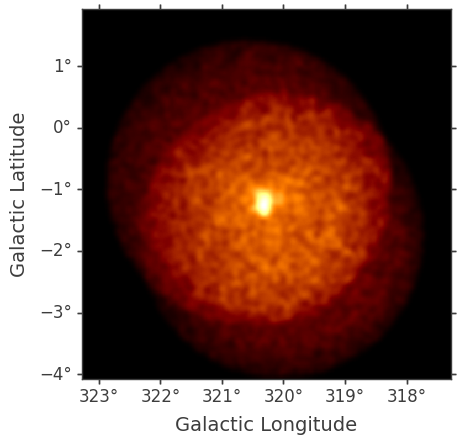

In [56]:
datasets_stacked.stack_reduce().counts.sum_over_axes(keepdims=False).smooth(
    0.05 * u.deg
).plot()

Just stack them before passing them to the `GammapyLike` instance or set the `mode="stacked"` so the plugin does it for you :) 

In [26]:
gl_stacked = GammapyLike("stacked", frame="galactic")
gl_stacked.set_datasets(datasets_stacked, mode="stacked")

Just the same model as before 

In [28]:
from astromodels.functions import Disk_on_sphere

In [29]:
from astromodels import *

In [100]:
cpl_stacked = Powerlaw()
spat_stacked = Gaussian_on_sphere(
    lon0=target_position.transform_to("galactic").l.deg,
    lat0=target_position.transform_to("galactic").b.deg,
    sigma=0.15,
)
es_stacked = ExtendedSource(
    source_name="rxj1713_stacked",
    spectral_shape=cpl_stacked,
    spatial_shape=spat_stacked,
)
cpl_stacked.K = 2.58e-12 / 3283 * u.Unit("TeV-1 cm-2 s-1")
cpl_stacked.index = -2.26 * u.dimensionless_unscaled
# cpl_stacked.xc = 8.5 * u.TeV
cpl_stacked.piv = 1 * u.TeV
cpl_stacked.piv.free = False
cpl_stacked.K.prior = Log_uniform_prior(lower_bound=1e-15, upper_bound=1e-8)
cpl_stacked.index.prior = Uniform_prior(lower_bound=-3, upper_bound=-1)
# cpl_stacked.xc.prior = Uniform_prior(lower_bound=1, upper_bound=30)
spat_stacked.lon0.free = False
spat_stacked.lat0.free = False
spat_stacked.sigma.free = True
spat_stacked.sigma.unit = u.deg
spat_stacked.sigma.prior = Log_uniform_prior(lower_bound=0.01, upper_bound=1)

model_stacked = Model(es_stacked)
conv_stacked = AstromodelConverter(model_stacked, "galactic")

Only Single Spectral Component Models currently supported


In [101]:
es_stacked

* rxj1713_stacked (extended source):
    * shape:
      * lon0:
        * value: 320.2781108123686
        * desc: Longitude of the center of the source
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * lat0:
        * value: -1.0728068313036465
        * desc: Latitude of the center of the source
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * sigma:
        * value: 0.15
        * desc: Standard deviation of the Gaussian distribution
        * min_value: 0.0
        * max_value: 20.0
        * unit: deg
        * is_normalization: false
    * spectrum:
      * main:
        * Powerlaw:
          * K:
            * value: 7.858665854401464e-16
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 1.0e-30
            * max_value: 1000.0
            * unit: TeV-1 s-1 cm-2
            * is_normalization: true
          * piv:
            * value: 1.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: TeV
            * is_normalization: false
          * index:
            * value: -2.26
            * desc: Photon index
            * min_value: -10.0
            * max_value: 10.0
            * unit: ''
            * is_normalization: false
        * polarization: {}

In [102]:
gl_stacked.set_model(model_stacked, conv_stacked)

If you want to specify sources for this Plugin you MUST do so before


For simplicity just use minuit to minimize the likelihood

In [103]:
gl_stacked.get_log_like()

-249946.43173679613

In [84]:
1509216 / 755

1998.9615894039734

In [99]:
from scipy.integrate import nquad

nquad(
    spat_stacked.evaluate,
    [(310, 330), (-10, 10)],
    args=(320.278110812368, -1.0728068, 0.15),
)

(3283.3856459336407, 3.1644392744709093e-07)

In [107]:
(180 / np.pi) ** 2

3282.806350011744

In [85]:
es_stacked.spectrum.main(1 * u.TeV) * es_stacked.spatial_shape(
    320.278, -1.072, 320.278, -1.072, 0.145
)

<Quantity 2.99547837e-11 1 / (TeV s cm2)>

In [104]:
gl_stacked.datasets[0]

In [92]:
ba2 = BayesianAnalysis(model_stacked, DataList(gl_stacked))

If you want to specify sources for this Plugin you MUST do so before


In [93]:
import time

In [ ]:
ba2.set_sampler("multinest")
ba2.sampler.setup(verbose=True, resume=False)
fit = ba2.sample()

08:41:00 INFO      sampler set to multinest                                                ]8;id=350969;file:///home/tobi/sw/threeML/threeML/bayesian/bayesian_analysis.py\bayesian_analysis.py]8;;\:]8;id=613461;file:///home/tobi/sw/threeML/threeML/bayesian/bayesian_analysis.py#186\186]8;;\

 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    3
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.993377
Replacements:                                450
Total Samples:                               453
Nested Sampling ln(Z):            **************
Acceptance Rate:                        0.974659
Replacements:                                500
Total Samples:                               513
Nested Sampling ln(Z):            **************
Acceptance Rate:                        0.932203
Replacements:                                550
Total Samples:                               590
Nested Sampling ln(Z):            **************
Acceptance Rate:                        0.899550
Replacements:                              

Exception ignored on calling ctypes callback function: <function run.<locals>.loglike at 0x7d55d12e9620>
Traceback (most recent call last):
  File "/home/tobi/bin/miniconda3/envs/threeml/lib/python3.11/site-packages/pymultinest/run.py", line 228, in loglike
    return LogLikelihood(cube, ndim, nparams)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tobi/sw/threeML/threeML/bayesian/sampler_base.py", line 468, in loglike
    log_like = self._log_like(trial_values)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tobi/sw/threeML/threeML/bayesian/sampler_base.py", line 356, in _log_like
    log_like_values[i] = dataset.get_log_like()
                         ^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tobi/bin/miniconda3/envs/threeml/lib/python3.11/site-packages/gammapy_plugin/GammapyLike.py", line 218, in get_log_like
    return -0.5 * self._datasets._stat_sum_likelihood()
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tobi/bin/miniconda3/envs/threeml

In [13]:
res = ba2.results

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

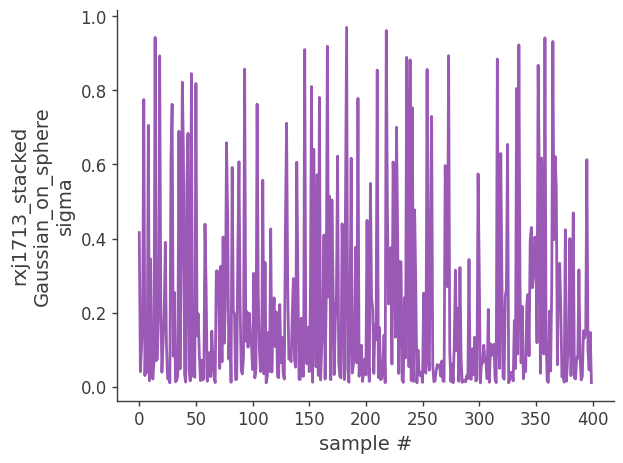

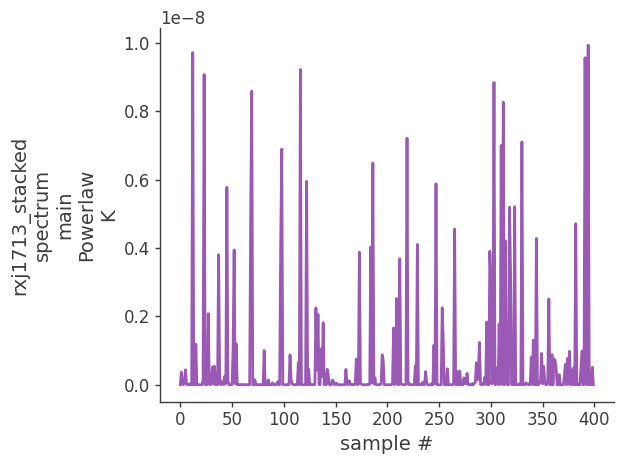

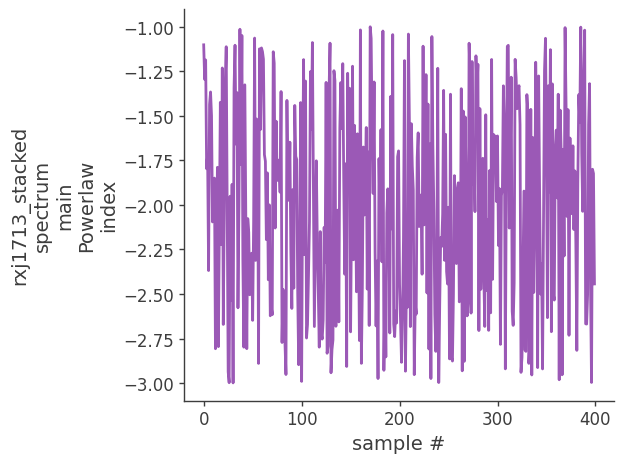

In [88]:
ba2.results.plot_chains()

In [14]:
res.display()

Maximum a posteriori probability (MAP) point:

,result,unit
parameter,,
rxj1713_stacked.Gaussian_on_sphere.sigma,(3.04 -0.12 +0.10) x 10^-1,deg
rxj1713_stacked.spectrum.main.Cutoff_powerlaw.K,(5.59 -0.5 +0.29) x 10^-15,1 / (TeV s cm2)
rxj1713_stacked...index,-1.70 -0.13 +0.11,
rxj1713_stacked.spectrum.main.Cutoff_powerlaw.xc,8.5 -1.9 +6,TeV


Values of -log(posterior) at the minimum:

,-log(posterior)
stacked,-253917.102512
total,-253917.102512


Values of statistical measures:

,statistical measures
AIC,507842.205042
BIC,507892.547499
DIC,507840.848020
PDIC,2.623461
log(Z),-110293.447120


In [19]:
res.optimized_model.extended_sources["rxj1713_stacked"].get_spatially_integrated_flux(
    1 * u.TeV
)

<Quantity 4.97492053e-15 1 / (TeV s cm2)>

In [32]:
es_stacked.get_spatially_integrated_flux(1), es_stacked.get_spatially_integrated_flux(
    1 * u.TeV
)

(array([5.2896081e-15]), <Quantity 5.2896081e-15 1 / (TeV s cm2)>)

In [81]:
import time

start = time.time()
jl.fit()
stop = time.time()
print(f"Fit finished in {round(stop-start,3)}s")
res_stacked = jl.results

Best fit values:

,result,unit
parameter,,
rxj1713_stacked.Gaussian_on_sphere.sigma,(1.33 +/- 0.08) x 10^-1,deg
rxj1713_stacked.spectrum.main.Powerlaw.K,(1.77 +/- 0.13) x 10^-15,1 / (TeV s cm2)
rxj1713_stacked.spectrum.main.Powerlaw.index,-2.46 +/- 0.08,


Correlation matrix:

1.00,0.53,-0.12
0.53,1.00,-0.20
-0.12,-0.20,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
stacked,249893.520582
total,249893.520582


Values of statistical measures:

,statistical measures
AIC,499793.041175
BIC,499830.798020


Fit finished in 18.151s


In [36]:
res_stacked.display()

Best fit values:

,result,unit
parameter,,
rxj1713_stacked.Disk_on_sphere.radius,(5.44 +/- 0.18) x 10^-1,deg
rxj1713_stacked.spectrum.main.Cutoff_powerlaw.K,(5.1 +/- 0.4) x 10^-15,1 / (TeV s cm2)
rxj1713_stacked...index,-1.66 +/- 0.14,
rxj1713_stacked.spectrum.main.Cutoff_powerlaw.xc,7.5 -2.3 +3.3,TeV


Correlation matrix:

1.00,0.23,0.16,-0.13
0.23,1.00,0.57,-0.75
0.16,0.57,1.00,-0.92
-0.13,-0.75,-0.92,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
stacked,253970.515548
total,253970.515548


Values of statistical measures:

,statistical measures
AIC,507949.031114
BIC,507999.373571


In [37]:
flux_1tev_stacked = res_stacked.optimized_model.extended_sources[
    "rxj1713_stacked"
].spectrum.main.shape(1 * u.TeV) * res_stacked.optimized_model.extended_sources[
    "rxj1713_stacked"
].spatial_shape.get_total_spatial_integral(
    z=1 * u.TeV
)

print(f"Flux: {flux_1tev_stacked}")

Flux: 4.483424860993724e-15 1 / (TeV s cm2)


In [40]:
es_stacked.spectrum.main(1 * u.TeV) * es_stacked.spatial_shape(
    target_position.l.deg, target_position.b.deg
)

<Quantity 1.58329599e-11 1 / (TeV s cm2)>

In [47]:
es_stacked.components["main"](1 * u.TeV) * (
    180 / 4 * np.pi
) ** 2  # /(0.5**2*np.pi)#*42000#*4*np.pi/(np.pi*0.5/180*np.pi)

<Quantity 8.96055002e-11 1 / (TeV s cm2)>

In [27]:
E = 1 * u.TeV
es_stacked.spatial_shape.get_total_spatial_integral(E) * es_stacked.spectrum.main.shape(
    E
)

<Quantity 4.94170803e-15 1 / (TeV s cm2)>

In [ ]:
spat_stacked.ndim

In [23]:
es_stacked.get_spatially_integrated_flux(1 * u.TeV)

<Quantity 4.93989443e-15 1 / (TeV s cm2)>

In [ ]:
e = np.geomspace(0.1, 50, 20) * u.TeV
plt.plot(e, es_stacked.get_spatially_integrated_flux(e))
plt.xscale("log")
plt.yscale("log")

In [ ]:
np.power(0.078, -1)

In [ ]:
es_stacked

In [1]:
from astromodels import *

07:10:23 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=129085;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=918841;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/functions.py#45\45]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=932252;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=859134;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/functions.py#67\67]8;;\
                  will not be available.                                                                           

07:10:24 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=55127;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=754258;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/absorption.py#34\34]8;;\
                  available                                                                                        

In [16]:
gauss = Gaussian_on_sphere()
cpl = Cutoff_powerlaw()
es = ExtendedSource("test", spatial_shape=gauss, spectral_shape=cpl)

In [18]:
cpl

* description: A power law multiplied by an exponential cutoff
  * formula: $ K~\frac{x}{piv}^{index}~\exp{-x/xc} $
  * parameters:
    * K:
      * value: 1.0
      * desc: Normalization (differential flux at the pivot value)
      * min_value: 1.0e-30
      * max_value: 1000.0
      * unit: TeV-1 s-1 cm-2
      * is_normalization: true
      * delta: 0.1
      * free: true
    * piv:
      * value: 1.0
      * desc: Pivot value
      * min_value: null
      * max_value: null
      * unit: TeV
      * is_normalization: false
      * delta: 0.1
      * free: false
    * index:
      * value: -2.0
      * desc: Photon index
      * min_value: -10.0
      * max_value: 10.0
      * unit: ''
      * is_normalization: false
      * delta: 0.2
      * free: true
    * xc:
      * value: 10.0
      * desc: Cutoff energy
      * min_value: 1.0
      * max_value: null
      * unit: TeV
      * is_normalization: false
      * delta: 1.0
      * free: true

In [22]:
es.spectrum.main(2 * u.TeV)

<Quantity 0.20468269 1 / (TeV s cm2)>

In [23]:
es.get_spatially_integrated_flux(2 * u.TeV)

<Quantity 0.20468269 1 / (TeV s cm2)>

In [20]:
E = 1 * u.TeV
es.spatial_shape.get_total_spatial_integral(E) * es.spectrum.main.shape(E)

<Quantity 8.12830516e-19 1 / (keV s cm2 deg2)>

Compared to the multiple hours `multinest` took to sample the full posterior using 10 threads this is way way faster at the cost of all the disadvantages of stacking the data ;)

In [108]:
os.environ["GAMMAPY_DATA"]

'/data/gammapy/gammapy-datasets/1.3'

Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)


Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)


MapDataset
----------

  Name                            : dataset-simu 

  Total counts                    : 148330 
  Total background counts         : 135697.88
  Total excess counts             : 12632.12

  Predicted counts                : 148046.48
  Predicted background counts     : 135697.88
  Predicted excess counts         : 12348.60

  Exposure min                    : 4.09e+09 m2 s
  Exposure max                    : 3.08e+11 m2 s

  Number of total bins            : 1187500 
  Number of fit bins              : 1187500 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : 764702.32

  Number of models                : 2 
  Number of parameters            : 11
  Number of free parameters       : 6

  Component 0: SkyModel
  
    Name                      : model-simu
    Datasets names            : None
    Spectral model type       : PowerLawSpectralModel
    Spatial  model type       : GaussianSpatialModel
    Temporal model type       : 
    Para

interactive(children=(SelectionSlider(continuous_update=False, description='Select energy:', layout=Layout(wid…

DatasetModels

Component 0: SkyModel

  Name                      : model-simu
  Datasets names            : None
  Spectral model type       : PowerLawSpectralModel
  Spatial  model type       : GaussianSpatialModel
  Temporal model type       : 
  Parameters:
    index                         :      3.000   +/-    0.00             
    amplitude                     :   1.00e-11   +/- 0.0e+00 1 / (TeV s cm2)
    reference             (frozen):      1.000       TeV         
    lon_0                         :      4.000   +/-    0.00 deg         
    lat_0                         :      0.100   +/-    0.00 deg         
    sigma                         :      0.300   +/-    0.00 deg         
    e                     (frozen):      0.000                   
    phi                   (frozen):      0.000       deg         

Component 1: FoVBackgroundModel

  Name                      : dataset-simu-bkg
  Datasets names            : ['dataset-simu']
  Spectral model type       : PowerLawN

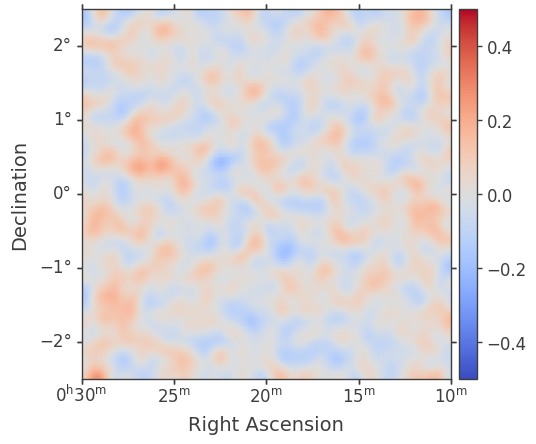

True model: 
 SkyModel

  Name                      : model-simu
  Datasets names            : None
  Spectral model type       : PowerLawSpectralModel
  Spatial  model type       : GaussianSpatialModel
  Temporal model type       : 
  Parameters:
    index                         :      3.000   +/-    0.00             
    amplitude                     :   1.00e-11   +/- 0.0e+00 1 / (TeV s cm2)
    reference             (frozen):      1.000       TeV         
    lon_0                         :      4.000   +/-    0.00 deg         
    lat_0                         :      0.100   +/-    0.00 deg         
    sigma                         :      0.300   +/-    0.00 deg         
    e                     (frozen):      0.000                   
    phi                   (frozen):      0.000       deg         

 

 Fitted model: 
 SkyModel

  Name                      : model-simu
  Datasets names            : None
  Spectral model type       : PowerLawSpectralModel
  Spatial  model type 

type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
,index,3.0283e+00,,1.863e-02,nan,nan,False,,
,amplitude,9.9778e-12,TeV-1 s-1 cm-2,1.338e-13,nan,nan,False,,
,reference,1.0000e+00,TeV,0.000e+00,nan,nan,True,,
,lon_0,3.9983e+00,deg,4.372e-03,nan,nan,False,,
,lat_0,1.0241e-01,deg,4.382e-03,-9.000e+01,9.000e+01,False,,
,sigma,2.9976e-01,deg,2.883e-03,0.000e+00,nan,False,,
,e,0.0000e+00,,0.000e+00,0.000e+00,1.000e+00,True,,
,phi,0.0000e+00,deg,0.000e+00,-1.800e+02,1.800e+02,True,,
,tilt,0.0000e+00,,0.000e+00,nan,nan,True,,


In [7]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt

# %matplotlib inline
from IPython.display import display
from gammapy.data import FixedPointingInfo, Observation, observatory_locations
from gammapy.datasets import MapDataset
from gammapy.irf import load_irf_dict_from_file
from gammapy.makers import MapDatasetMaker, SafeMaskMaker
from gammapy.maps import MapAxis, WcsGeom
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    FoVBackgroundModel,
    GaussianSpatialModel,
    Models,
    PowerLawSpectralModel,
    SkyModel,
)

# Loading IRFs
irfs = load_irf_dict_from_file(
    "$GAMMAPY_DATA/cta-1dc/caldb/data/cta/1dc/bcf/South_z20_50h/irf_file.fits"
)
# Define the observation parameters (typically the observation duration and the pointing position):
livetime = 20.0 * u.hr
pointing_position = SkyCoord(ra=5, dec=0, unit="deg", frame="icrs")
# We want to simulate an observation pointing at a fixed position in the sky.
# For this, we use the `FixedPointingInfo` class
pointing = FixedPointingInfo(
    fixed_icrs=pointing_position.icrs,
)

# Define map geometry for binned simulation
energy_reco = MapAxis.from_edges(
    np.geomspace(0.5, 10, 20), unit="TeV", name="energy", interp="log"
)
geom = WcsGeom.create(
    skydir=pointing_position,
    binsz=0.02,
    width=(5, 5),
    frame="icrs",
    axes=[energy_reco],
)
# It is usually useful to have a separate binning for the true energy axis
energy_true = MapAxis.from_edges(
    np.geomspace(0.2, 20, 40), unit="TeV", name="energy_true", interp="log"
)

empty = MapDataset.create(geom, name="dataset-simu", energy_axis_true=energy_true)

# Define sky model to used simulate the data.
# Here we use a Gaussian spatial model and a Power Law spectral model.
spatial_model = GaussianSpatialModel(
    lon_0="4 deg", lat_0="0.1 deg", sigma="0.3 deg", frame="icrs"
)
spectral_model = PowerLawSpectralModel(
    index=3, amplitude="1e-11 cm-2 s-1 TeV-1", reference="1 TeV"
)
model_simu = SkyModel(
    spatial_model=spatial_model,
    spectral_model=spectral_model,
    name="model-simu",
)

bkg_model = FoVBackgroundModel(dataset_name="dataset-simu")

models = Models([model_simu, bkg_model])
# print(models)


######################################################################
# Now, comes the main part of dataset simulation. We create an in-memory
# observation and an empty dataset. We then predict the number of counts
# for the given model, and Poisson fluctuate it using ``fake()`` to make
# a simulated counts maps. Keep in mind that it is important to specify
# the ``selection`` of the maps that you want to produce
#

# Create an in-memory observation
location = observatory_locations["ctao_south"]
obs = Observation.create(
    pointing=pointing, livetime=livetime, irfs=irfs, location=location
)
# print(obs)

# Make the MapDataset
maker = MapDatasetMaker(selection=["exposure", "background", "psf", "edisp"])

maker_safe_mask = SafeMaskMaker(methods=["offset-max"], offset_max=4.0 * u.deg)

dataset = maker.run(empty, obs)
dataset = maker_safe_mask.run(dataset, obs)
# print(dataset)

# Add the model on the dataset and Poisson fluctuate
dataset.models = models
dataset.fake()

fake_dataset = dataset.copy()
# Do a print on the dataset - there is now a counts maps
print(dataset)


dataset.counts.smooth(0.05 * u.deg).plot_interactive(add_cbar=True, stretch="linear")
plt.show()

models_fit = models.copy()

# We do not want to fit the background in this case, so we will freeze the parameters
models_fit["dataset-simu-bkg"].spectral_model.norm.frozen = True
models_fit["dataset-simu-bkg"].spectral_model.tilt.frozen = True

dataset.models = models_fit
print(dataset.models)

fit = Fit(optimize_opts={"print_level": 1})
result = fit.run(datasets=[dataset])

dataset.plot_residuals_spatial(method="diff/sqrt(model)", vmin=-0.5, vmax=0.5)
plt.show()


######################################################################
# Compare the injected and fitted models:
#

print(
    "True model: \n",
    model_simu,
    "\n\n Fitted model: \n",
    models_fit["model-simu"],
)


######################################################################
# Get the errors on the fitted parameters from the parameter table
#

display(result.parameters.to_table())

In [97]:
gl_fake = GammapyLike(name="fake_ds", frame="icrs")
fake_dataset
fake_dataset.models = []

In [98]:
gl_fake.set_datasets(fake_dataset)

In [99]:
bkg_model_fake = FoVBackgroundModel(
    name="test_fake_bkg", dataset_name=fake_dataset.name
)

In [100]:
gl_fake.set_background_models(bkg_model_fake)

In [101]:
from astromodels import *

In [102]:
pl = Powerlaw()
gauss = Gaussian_on_sphere()
es_fake = ExtendedSource(
    "fake_it_til_you_make_it", spatial_shape=gauss, spectral_shape=pl
)

In [103]:
pl.K.min_value = 1e-20 * u.Unit("cm-2 s-1 TeV-1")
pl.K.max_value = 1e-5 * u.Unit("cm-2 s-1 TeV-1")
pl.K = 2e-11 * u.Unit("cm-2 s-1 TeV-1")
pl.K.set_uninformative_prior(Log_uniform_prior)

10:35:10 WARNING   The current value of the parameter K (1.0) was above the new maximum 1e-05.     ]8;id=215628;file:///home/tobi/sw/astromodels/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=541618;file:///home/tobi/sw/astromodels/astromodels/core/parameter.py#810\810]8;;\

In [104]:
pl.piv = 1 * u.TeV

pl.index.min_value = -5
pl.index.max_value = -1
pl.index.value = -2.5
pl.index.prior = Uniform_prior(lower_bound=-5, upper_bound=-1)

In [128]:
gauss.lon0.min_value = 3.5
gauss.lon0.max_value = 4.5
gauss.lon0 = 4.1
gauss.lon0.free = True

gauss.lon0.set_uninformative_prior(Uniform_prior)


gauss.lat0.min_value = -1
gauss.lat0.max_value = 1
gauss.lat0 = 0
gauss.lat0.free = True
gauss.lat0.set_uninformative_prior(Uniform_prior)
gauss.sigma = 0.1 * u.deg
gauss.sigma.free = True
gauss.sigma.max_value = 2
gauss.sigma.prior = Log_uniform_prior(lower_bound=1e-2, upper_bound=1)

In [129]:
model = Model(es_fake)

In [130]:
model

Model summary:
==============

                  N
Point sources     0
Extended sources  1
Particle sources  0

Free parameters (5):
--------------------

                                    value min_value max_value            unit
fake_it_til_you_make_it...lon0        4.1       3.5       4.5             deg
fake_it_til_you_make_it...lat0        0.0      -1.0       1.0             deg
fake_it_til_you_make_it...sigma       0.1       0.0       2.0             deg
fake_it_til_you_make_it...K           0.0       0.0   0.00001  TeV-1 s-1 cm-2
fake_it_til_you_make_it...index -3.082562      -5.0      -1.0                

Fixed parameters (1):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [131]:
conv = AstromodelConverter(model, frame="icrs")

In [132]:
gl_fake.set_model(model, conv)

In [133]:
model

Model summary:
==============

                  N
Point sources     0
Extended sources  1
Particle sources  0

Free parameters (5):
--------------------

                                    value min_value max_value            unit
fake_it_til_you_make_it...lon0        4.1       3.5       4.5             deg
fake_it_til_you_make_it...lat0        0.0      -1.0       1.0             deg
fake_it_til_you_make_it...sigma       0.1       0.0       2.0             deg
fake_it_til_you_make_it...K           0.0       0.0   0.00001  TeV-1 s-1 cm-2
fake_it_til_you_make_it...index -3.082562      -5.0      -1.0                

Fixed parameters (1):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [134]:
model.fake_it_til_you_make_it.spectrum.main.shape.K.value = 9e-11

In [135]:
print(gl_fake.get_log_like())

-471586.2443486257


In [136]:
lls = []
x = np.geomspace(0.01, 10000, 100)
for K in x:
    model.fake_it_til_you_make_it.spectrum.main.shape.K.value = K * 1e-11
    lls.append(gl_fake.get_log_like())

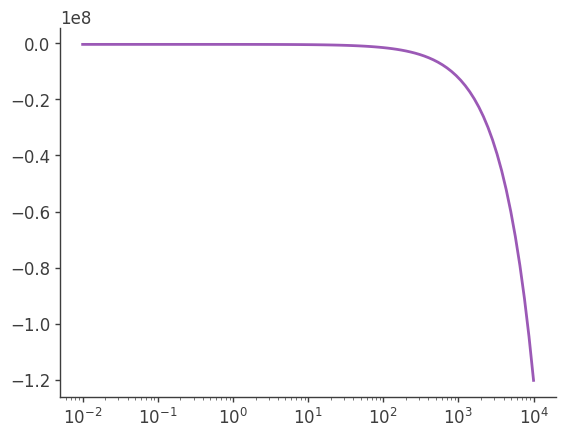

In [137]:
plt.plot(x, lls)
plt.xscale("log")

In [138]:
SkyCoord(ra=30, dec=0, unit="deg", frame="icrs").transform_to("galactic")

<SkyCoord (Galactic): (l, b) in deg
    (157.00523072, -58.26163724)>

In [139]:
# model.fake_it_til_you_make_it.spatial_shape.lat0.value = 0

In [140]:
print(gl_fake.get_log_like())
gl_fake.gammapy_model["fake_it_til_you_make_it"]

-120174970.00651388


SkyModel(spatial_model=<gammapy_plugin.models.SpatialModelConverted object at 0x775a60bdcd50>, spectral_model=<gammapy_plugin.models.SpectralModelConverted object at 0x775a60b26210>)temporal_model=None)

In [141]:
ba = BayesianAnalysis(model, data_list=DataList(gl_fake))

In [142]:
ba.set_sampler("multinest")
ba.sampler.setup(verbose=True, resume=False)

10:54:14 INFO      sampler set to multinest                                                ]8;id=423456;file:///home/tobi/sw/threeML/threeML/bayesian/bayesian_analysis.py\bayesian_analysis.py]8;;\:]8;id=703889;file:///home/tobi/sw/threeML/threeML/bayesian/bayesian_analysis.py#186\186]8;;\

In [143]:
ba.sample()

 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    6
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.991189
Replacements:                                450
Total Samples:                               454
Nested Sampling ln(Z):            **************
Acceptance Rate:                        0.972763
Replacements:                                500
Total Samples:                               514
Nested Sampling ln(Z):            **************
Acceptance Rate:                        0.953206
Replacements:                                550
Total Samples:                               577
Nested Sampling ln(Z):            -753135.562254
Acceptance Rate:                        0.921659
Replacements:                              

11:23:15 INFO      fit restored to maximum of posterior                                         ]8;id=585826;file:///home/tobi/sw/threeML/threeML/bayesian/sampler_base.py\sampler_base.py]8;;\:]8;id=457501;file:///home/tobi/sw/threeML/threeML/bayesian/sampler_base.py#167\167]8;;\

         INFO      fit restored to maximum of posterior                                         ]8;id=942488;file:///home/tobi/sw/threeML/threeML/bayesian/sampler_base.py\sampler_base.py]8;;\:]8;id=227131;file:///home/tobi/sw/threeML/threeML/bayesian/sampler_base.py#167\167]8;;\

11:23:15 WARNING   The current value of the parameter lon0 (0.0) was below the new minimum 3.5.    ]8;id=550695;file:///home/tobi/sw/astromodels/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=637450;file:///home/tobi/sw/astromodels/astromodels/core/parameter.py#732\732]8;;\

         WARNING   The current value of the parameter sigma (10.0) was above the new maximum 2.0.  ]8;id=69986;file:///home/tobi/sw/astromodels/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=838404;file:///home/tobi/sw/astromodels/astromodels/core/parameter.py#810\810]8;;\

...

,result,unit
parameter,,
fake_it_til_you_make_it.Gaussian_on_sphere.lon0,3.998 +/- 0.004,deg
fake_it_til_you_make_it.Gaussian_on_sphere.lat0,(1.01 -0.04 +0.05) x 10^-1,deg
fake_it_til_you_make_it.Gaussian_on_sphere.sigma,(2.972 -0.025 +0.034) x 10^-1,deg
fake_it_til_you_make_it.spectrum.main.Powerlaw.K,(1.003 -0.010 +0.017) x 10^-11,1 / (TeV s cm2)
fake_it_til_you_make_it...index,-3.083 -0.014 +0.025,
fake_ds_test_fake_bkg_norm,1.0060 -0.004 +0.0017,


Values of -log(posterior) at the minimum:

,-log(posterior)
fake_ds,-382504.162487
total,-382504.162487


Values of statistical measures:

,statistical measures
AIC,765020.325044
BIC,765092.249138
DIC,765019.908329
PDIC,5.932573
log(Z),-166144.276655


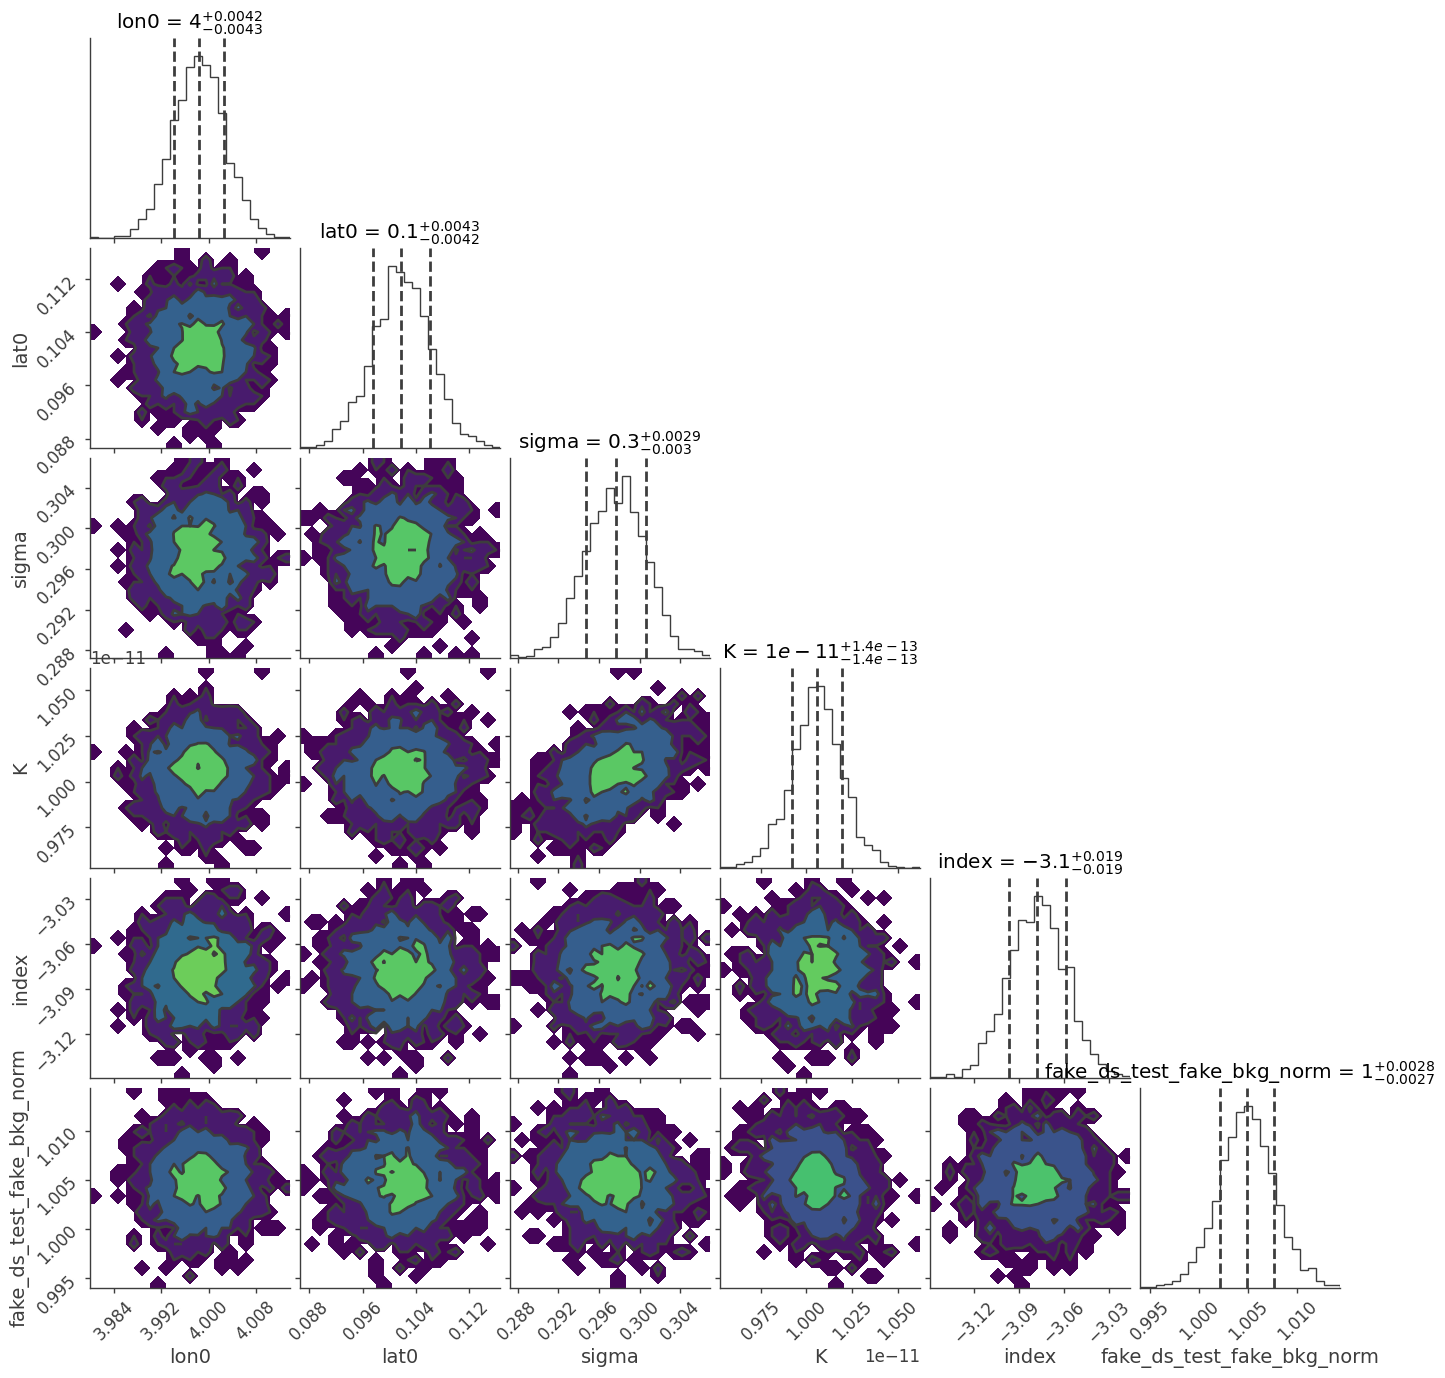

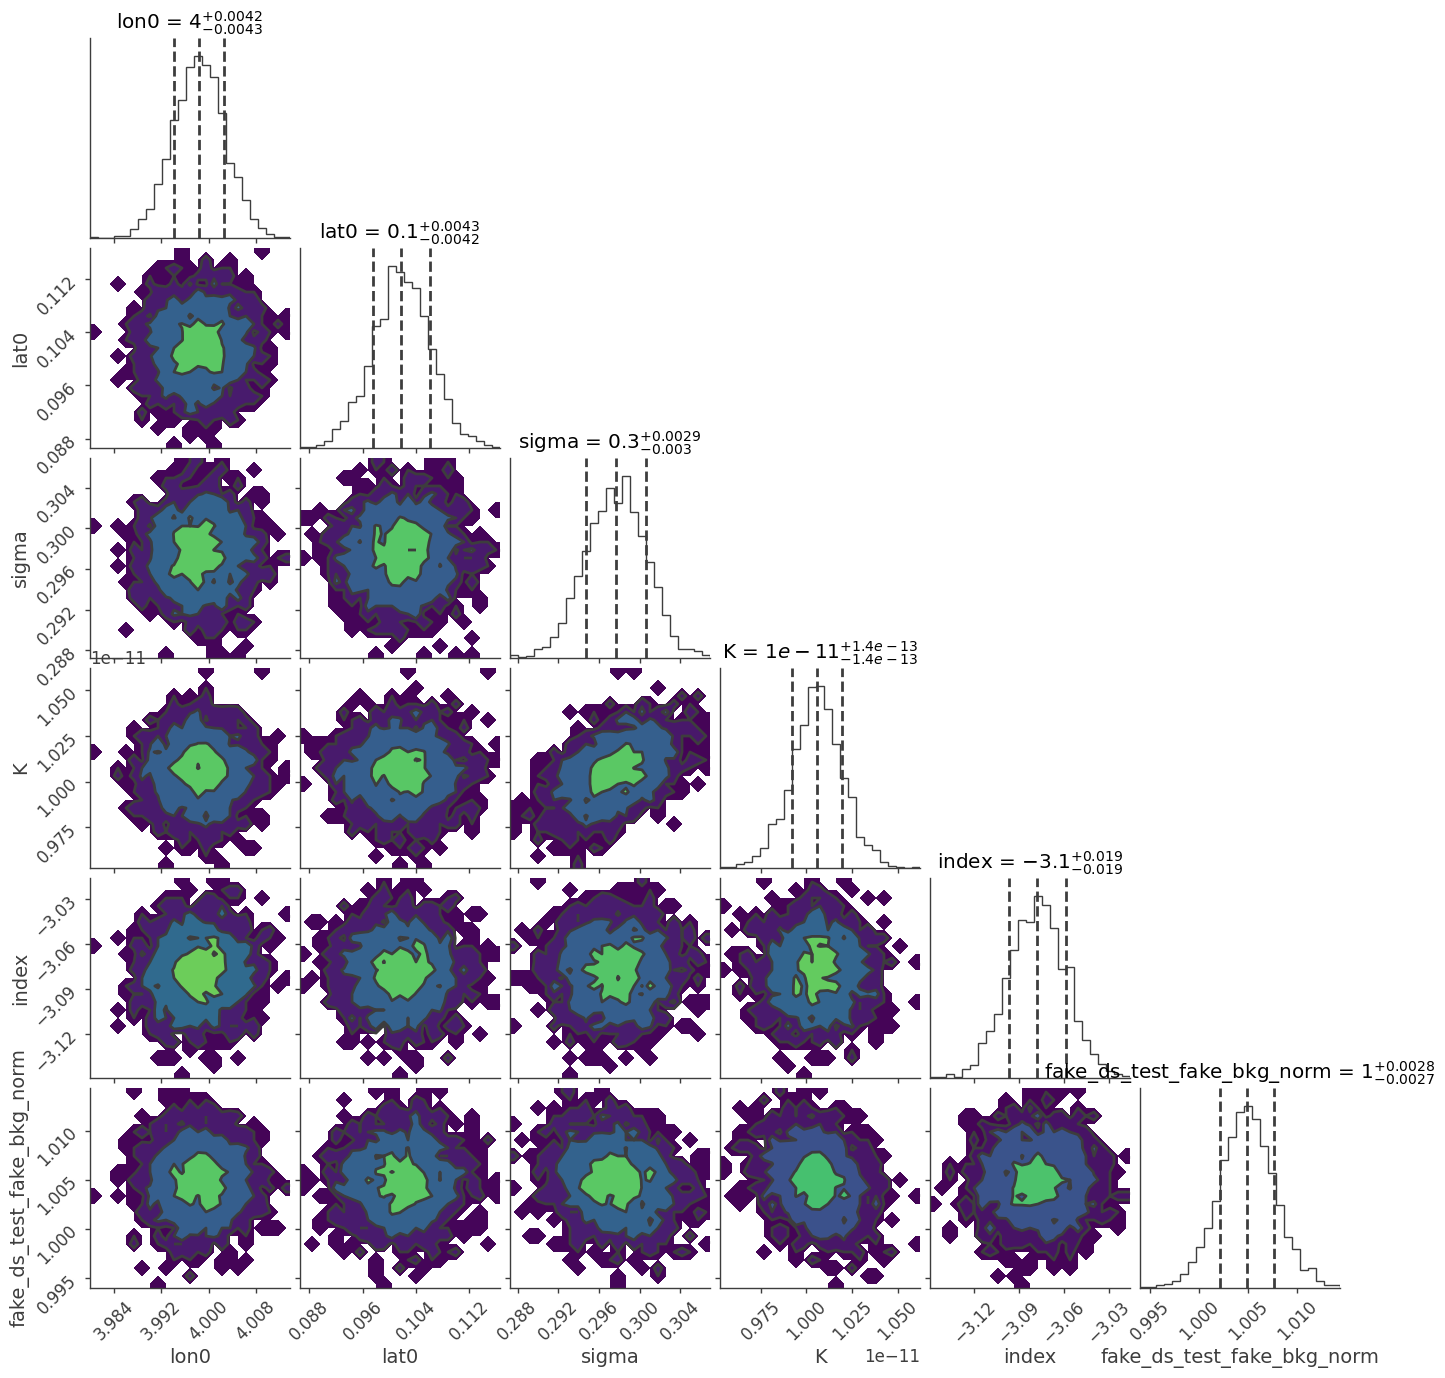

In [144]:
ba.results.corner_plot()

In [145]:
gl_fake.datasets[0].counts.smooth(0.05 * u.deg).plot_interactive(
    add_cbar=True, stretch="linear"
)

interactive(children=(SelectionSlider(continuous_update=False, description='Select energy:', layout=Layout(wid…

<WCSAxes: >

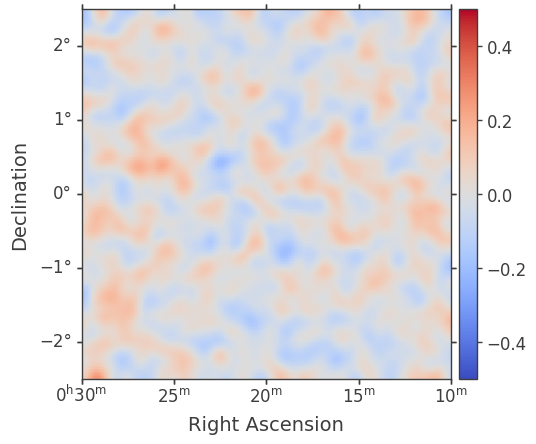

In [146]:
gl_fake.datasets[0].plot_residuals_spatial(
    method="diff/sqrt(model)", vmin=-0.5, vmax=0.5
)

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

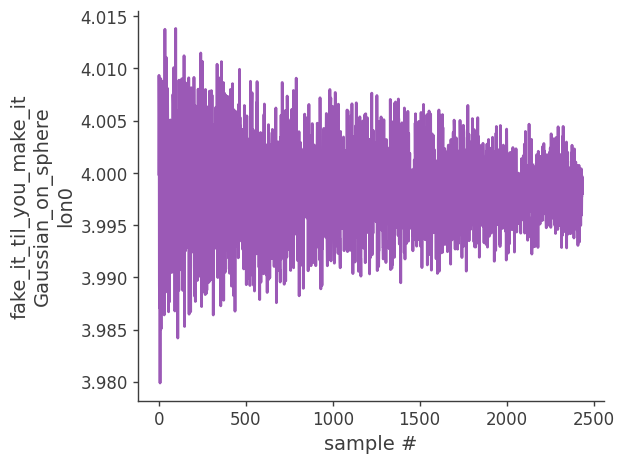

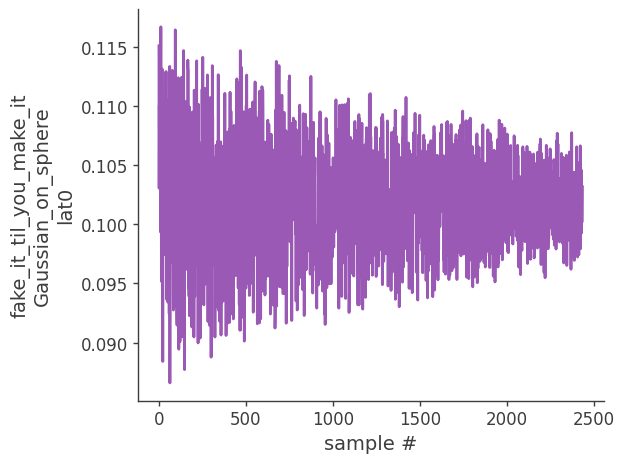

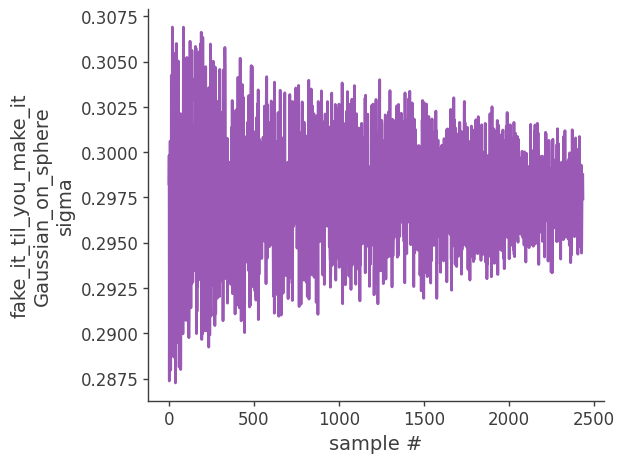

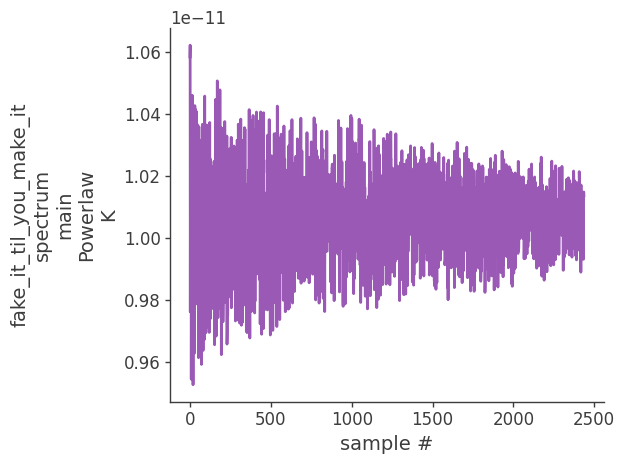

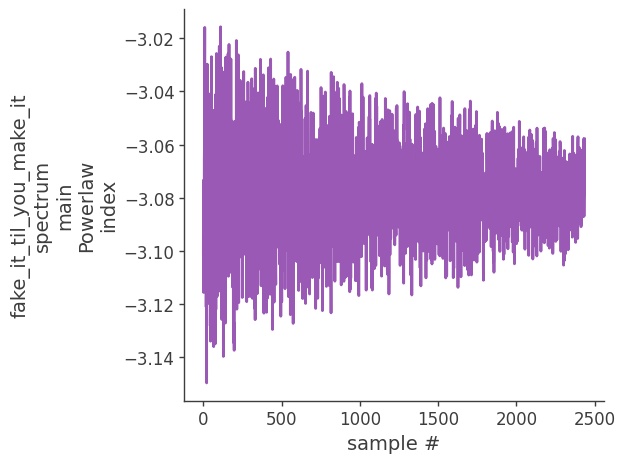

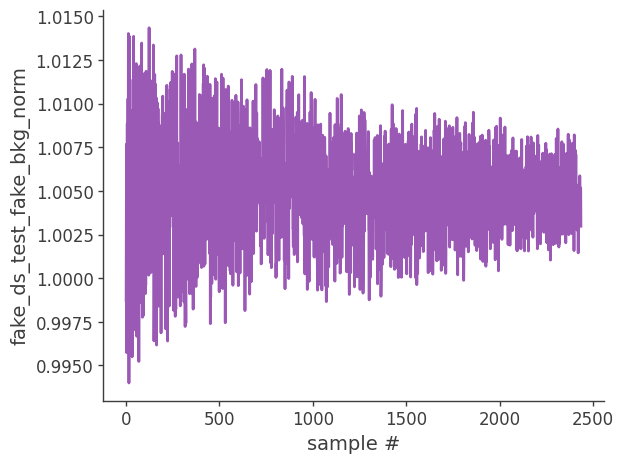

In [147]:
ba.results.plot_chains()